# Chatbot: Overview and Goals

This notebook builds a simple conversational model (seq2seq) from a publicly-available dialogue dataset. It demonstrates the full workflow: load and explore data, prepare tokenized input/output sequences, train an encoder–decoder model, save the model, and run inference.

Why: understanding a working seq2seq pipeline teaches how sequence modeling, teacher-forcing, and decoding work — foundational skills for chatbots and many NLP tasks.

What to expect from the code cells that follow:
- Data preparation: creating input-response pairs, tokenization, and padding.
- Model: embedding + LSTM encoder and LSTM decoder with softmax output.
- Training: teacher forcing with sparse categorical crossentropy.
- Inference: reconstructing encoder and single-step decoder for response generation.

In [13]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.models import Model
from datasets import load_dataset
import tensorflow_datasets as tfds
import tensorflow_datasets.public_api as tfds_public 
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Loading And Preparing Data
What this cell does:
- Tries to load a conversational dataset from TensorFlow Datasets and converts each dialogue into input-response pairs.
- Falls back to a small built-in dialogue set if the dataset is not available locally.

Why it matters:
- A chatbot learns to map user utterances (encoder input) to agent replies (decoder target). Preparing aligned pairs is essential for supervised training.

Key concepts:
- Tokenization: mapping words to integer IDs for neural network consumption.
- Padding: ensuring fixed-length sequences for batch training.
- Start/End tokens: signal decoder start and termination during inference.


In [17]:
# Load a conversational dataset and prepare input-response pairs
print('Loading dialogue data (may take a moment)')

inputs = []
responses = []

try:
    # Load DailyDialog from Hugging Face datasets
    dataset = load_dataset("daily_dialog", trust_remote_code=True)

    # Iterate through the training split
    for ex in dataset['train']:
        # 'dialog' is a list of strings representing conversation turns
        dialog = ex['dialog']
        
        # Extract context-response training pairs
        for i in range(len(dialog) - 1):
            inputs.append(dialog[i].strip())
            responses.append(dialog[i + 1].strip())

    print(f'Loaded DailyDialog successfully! Total pairs: {len(inputs)}')
    
except Exception as e:
    print(f'Could not load DailyDialog. Error: {e}\nUsing a built-in fallback dataset.')

    # Your fallback pairs here...
    fallback_pairs = [
        ('hello', 'hi there'),
        ('hi', 'hello, how can I help you?'),
        # ... rest of your fallback data
    ]

    inputs = [pair[0] for pair in fallback_pairs]
    responses = [pair[1] for pair in fallback_pairs]

    fallback_pairs = [
        ('hello', 'hi there'),
        ('hi', 'hello, how can I help you?'),
        ('good morning', 'good morning, what can I do for you?'),
        ('good evening', 'good evening, how can I help?'),
        ('how are you', 'i am doing well, thank you'),
        ('what can you do', 'i can answer simple questions and chat with you'),
        ('tell me a joke', 'why did the notebook go to class? to keep its cells in order'),
        ('thank you', 'you are welcome'),
        ('thanks', 'you are welcome'),
        ('what is your name', 'i am a simple chatbot model'),
        ('who are you', 'i am a simple chatbot model'),
        ('can you help me', 'yes, tell me what you need help with'),
        ('i need help with my order', 'please share your order number and issue'),
        ('i have a question', 'sure, ask your question'),
        ('what time is it', 'i do not have a clock, but your system time should be available'),
        ('where are you from', 'i live in this notebook environment'),
        ('do you understand me', 'i am trying my best to understand'),
        ('goodbye', 'goodbye, take care'),
        ('bye', 'see you later'),
        ('are you real', 'i am a software model running in a notebook'),
        ('what is ai', 'ai is software that performs tasks that usually need human intelligence'),
        ('what is machine learning', 'machine learning helps models learn patterns from data'),
        ('explain tensorflow', 'tensorflow is a library for machine learning and deep learning'),
        ('what is a chatbot', 'a chatbot is a program that can hold a conversation'),
        ('how does this work', 'it maps an input sentence to a response sentence'),
        ('can you repeat that', 'it maps an input sentence to a response sentence'),
        ('i am happy', 'that is great to hear'),
        ('i am sad', 'i am sorry to hear that'),
        ('what should i do', 'please tell me more about the situation'),
        ('help', 'i am here to help'),
    ]

    inputs = [pair[0] for pair in fallback_pairs]
    responses = [pair[1] for pair in fallback_pairs]

# Limit dataset size for a runnable example (adjust as needed)
max_pairs = 20000
inputs = inputs[:max_pairs]
responses = responses[:max_pairs]

# Add simple start/end tokens to responses for decoder training
responses = ["<start> " + r + " <end>" for r in responses]

print(f"Prepared {len(inputs)} input-response pairs")

# Tokenize
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(inputs + responses)

input_seqs = tokenizer.texts_to_sequences(inputs)
response_seqs = tokenizer.texts_to_sequences(responses)

max_encoder_seq_length = max(len(s) for s in input_seqs)
max_decoder_seq_length = max(len(s) for s in response_seqs)

encoder_input_data = pad_sequences(input_seqs, maxlen=max_encoder_seq_length, padding='post')
response_padded = pad_sequences(response_seqs, maxlen=max_decoder_seq_length, padding='post')

decoder_input_data = response_padded[:, :-1]
decoder_target_data = response_padded[:, 1:]

print('Shapes:')
print('  encoder_input_data:', encoder_input_data.shape)
print('  decoder_input_data:', decoder_input_data.shape)
print('  decoder_target_data:', decoder_target_data.shape)

# Train/validation split
from sklearn.model_selection import train_test_split
enc_in_train, enc_in_val, dec_in_train, dec_in_val, dec_tar_train, dec_tar_val = train_test_split(
    encoder_input_data, decoder_input_data, decoder_target_data, test_size=0.2, random_state=42
)


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'daily_dialog' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'daily_dialog' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading dialogue data (may take a moment)
Could not load DailyDialog. Error: Dataset scripts are no longer supported, but found daily_dialog.py
Using a built-in fallback dataset.
Prepared 30 input-response pairs
Shapes:
  encoder_input_data: (30, 6)
  decoder_input_data: (30, 14)
  decoder_target_data: (30, 14)


Sample input-response pairs:

1) Input: hello
   Response: <start> hi there <end>

2) Input: hi
   Response: <start> hello, how can I help you? <end>

3) Input: good morning
   Response: <start> good morning, what can I do for you? <end>

4) Input: good evening
   Response: <start> good evening, how can I help? <end>

5) Input: how are you
   Response: <start> i am doing well, thank you <end>

6) Input: what can you do
   Response: <start> i can answer simple questions and chat with you <end>

7) Input: tell me a joke
   Response: <start> why did the notebook go to class? to keep its cells in order <end>

8) Input: thank you
   Response: <start> you are welcome <end>

9) Input: thanks
   Response: <start> you are welcome <end>

10) Input: what is your name
   Response: <start> i am a simple chatbot model <end>



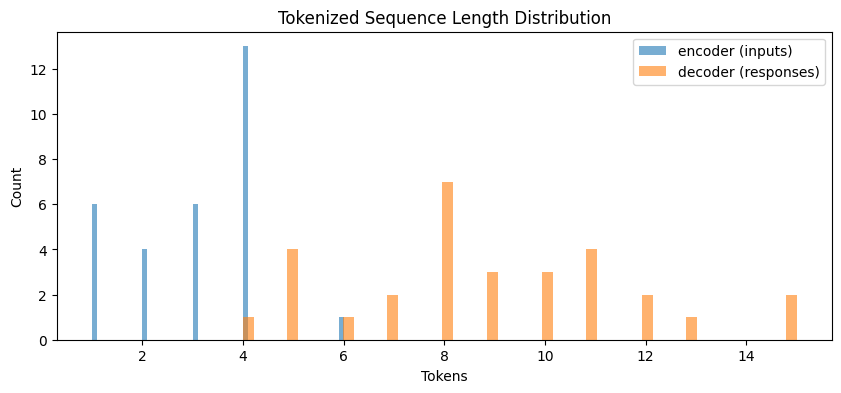

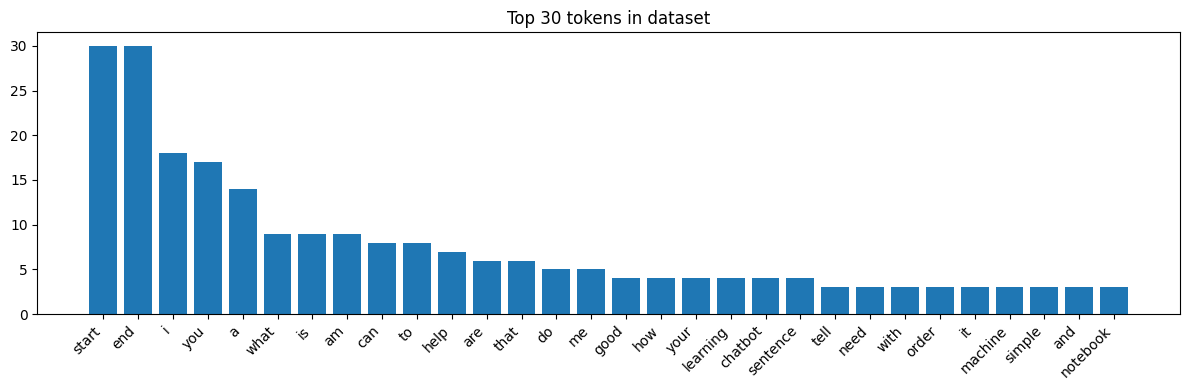

In [18]:
# Visualize sample dialogues and token distributions
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Show a few sample input-response pairs
print("Sample input-response pairs:\n")
for i in range(min(10, len(inputs))):
    print(f"{i+1}) Input: {inputs[i]}")
    print(f"   Response: {responses[i]}")
    print()

# Sequence length distributions
enc_lens = [len(s) for s in input_seqs]
dec_lens = [len(s) for s in response_seqs]

plt.figure(figsize=(10,4))
plt.hist(enc_lens, bins=50, alpha=0.6, label='encoder (inputs)')
plt.hist(dec_lens, bins=50, alpha=0.6, label='decoder (responses)')
plt.title('Tokenized Sequence Length Distribution')
plt.xlabel('Tokens')
plt.ylabel('Count')
plt.legend()
plt.show()

# Token frequency (top 30)
most_common = Counter(tokenizer.word_counts).most_common(30)
if most_common:
    words, counts = zip(*most_common)
    plt.figure(figsize=(12,4))
    plt.bar(words, counts, color='tab:blue')
    plt.xticks(rotation=45, ha='right')
    plt.title('Top 30 tokens in dataset')
    plt.tight_layout()
    plt.show()
else:
    print('No token counts available.')

# Model Architecture (Encoder–Decoder)

What this cell does:
- Builds an encoder (Embedding → LSTM) that reads the input sentence and compresses it into a state vector.
- Builds a decoder (Embedding → LSTM → Dense) that uses the encoder states to generate a probability distribution over vocabulary tokens at each timestep.

Why this architecture:
- Sequence-to-sequence models are the classic approach for conditional text generation tasks such as translation and chat.
- The encoder summarizes the context; the decoder uses that summary plus previous tokens (teacher forcing during training) to predict the next token.

Key concepts and APIs:
- `Embedding`: learns dense word vectors during training.
- `LSTM`: maintains and updates hidden and cell states across time steps.
- `return_state=True`: needed to access encoder states for initialising the decoder.

Common mistakes:
- Using one-hot targets with `sparse_categorical_crossentropy` (use integer class labels instead).
- Forgetting `mask_zero=True` in the embedding when using padded token `0`.

In [19]:
# Build a simple seq2seq model (encoder-decoder) using the tokenized data
from tensorflow.keras.layers import Embedding, LSTM
from tensorflow.keras import layers
from tensorflow.keras.models import Model

latent_dim = 256
embedding_dim = 256

# Reuse vocab_size from tokenizer; ensure +1 for reserved index
vocab = min(vocab_size, len(tokenizer.word_index) + 1)

# Encoder
encoder_inputs = tf.keras.Input(shape=(None,), name='encoder_inputs')
enc_emb = Embedding(vocab, embedding_dim, mask_zero=True, name='encoder_embedding')(encoder_inputs)
encoder_lstm = LSTM(latent_dim, return_state=True, name='encoder_lstm')
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = tf.keras.Input(shape=(None,), name='decoder_inputs')
dec_emb_layer = Embedding(vocab, embedding_dim, mask_zero=True, name='decoder_embedding')
dec_emb = dec_emb_layer(decoder_inputs)
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, name='decoder_lstm')
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
decoder_dense = layers.Dense(vocab, activation='softmax', name='decoder_dense')
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, None, 256) │     32,768 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, None)      │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, None, 256) │     32,768 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    525,312 │ encoder_embeddin… │
│                     │ (None, 256),      │            │ not_equal_2[0][0] │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │    525,312 │ decoder_embeddin… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None, 128) │     32,896 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,149,056 (4.38 MB)

 Trainable params: 1,149,056 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Train the seq2seq model (teacher forcing)
# decoder target data needs to have shape (batch, seq_len) with integer class labels

batch_size = 64
epochs = 10

history = model.fit(
    [enc_in_train, dec_in_train],
    dec_tar_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=([enc_in_val, dec_in_val], dec_tar_val)
)

# Save trained model weights (model architecture+weights)
model.save('chatbot_seq2seq_daily_dialog.keras')
print('Saved seq2seq model: chatbot_seq2seq_daily_dialog.keras')

Epoch 1/10


I0000 00:00:1781189520.096163   38355 cuda_dnn.cc:461] Loaded cuDNN version 92300


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.0091 - loss: 4.8519 - val_accuracy: 0.2174 - val_loss: 4.8376
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.1591 - loss: 4.8373 - val_accuracy: 0.2174 - val_loss: 4.8247
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.1727 - loss: 4.8249 - val_accuracy: 0.2174 - val_loss: 4.8117
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.1773 - loss: 4.8123 - val_accuracy: 0.2391 - val_loss: 4.7972
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.1773 - loss: 4.7982 - val_accuracy: 0.2391 - val_loss: 4.7799
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.1773 - loss: 4.7815 - val_accuracy: 0.2391 - val_loss: 4.7574
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.1727 - loss: 4.7597 - val_accuracy: 0.2174 - val_loss: 4.7251
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.1682 - loss: 4.7284 - val_accuracy: 0.2174 - val_loss: 4.6725
Epoch 

# Training: Teacher Forcing and Optimization

What this cell does:
- Trains the seq2seq model using encoder inputs and shifted decoder inputs (teacher forcing).

Why teacher forcing:
- At training time, providing the ground-truth previous token to the decoder (instead of its own prediction) stabilises and speeds up training.

Training details to consider:
- Loss: `sparse_categorical_crossentropy` (targets are integer token IDs).
- Optimizer: `rmsprop` (commonly used for seq2seq); you can try `adam` as well.
- Validation split: helps detect overfitting during training.

Practical tips:
- Keep batch size and sequence lengths reasonable to fit GPU/CPU memory.
- Monitor validation loss and accuracy; if validation diverges, reduce model capacity or use regularization.

Interview question:
- What are the trade-offs of teacher forcing vs. scheduled sampling during seq2seq training?

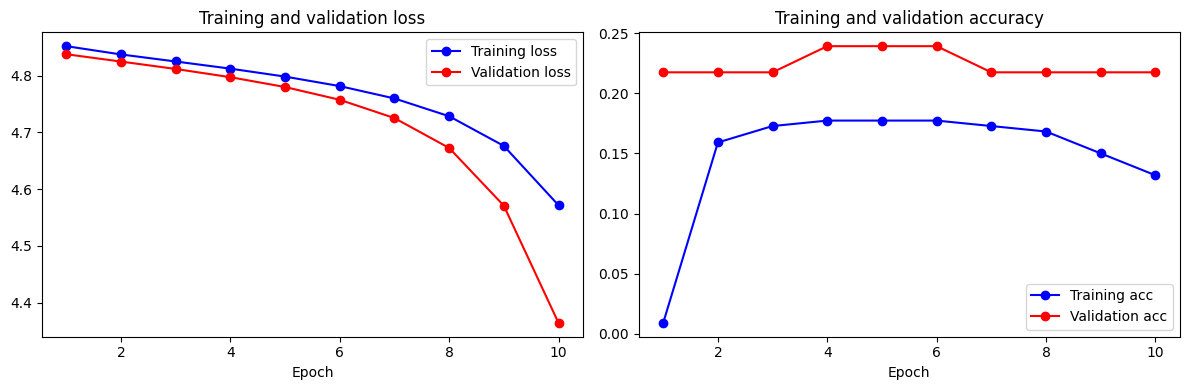

In [21]:
# Plot training history (loss and accuracy)
import matplotlib.pyplot as plt

if 'history' in globals():
    hist = history.history
    epochs = range(1, len(hist['loss'])+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, hist['loss'], 'bo-', label='Training loss')
    plt.plot(epochs, hist.get('val_loss', []), 'ro-', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, hist.get('accuracy', []), 'bo-', label='Training acc')
    plt.plot(epochs, hist.get('val_accuracy', []), 'ro-', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print('No training history found. Run the training cell first.')

# Saving the Model

What this cell does:
- Persists model weights and architecture to disk so the trained model can be reloaded later for inference or deployment.

Why it matters:
- Saving allows you to avoid retraining and to serve the model in production or evaluate it offline.

Notes:
- Keras `.save()` writes an HDF5 or TF SavedModel-style file depending on your Keras version and filename. Use a clear name and include metadata (vocab/tokenizer) needed for inference.
- Also save the `tokenizer` and any preprocessing parameters (e.g., `max_encoder_seq_length`) so inference can reproduce training preprocessing exactly.

In [22]:
# Save the model
model.save('chatbot_model.keras')

# Inference: Reconstructing Decoder for Generation

What this cell does:
- Builds smaller inference-time encoder and decoder models: the encoder outputs states; the decoder runs one timestep at a time using previous predicted token + states to produce the next token.

Why different models are needed for inference:
- During training we use teacher forcing with whole target sequences; at inference we must generate tokens step-by-step from model predictions.

Important details:
- The decoding loop uses `argmax` sampling here; for better-quality responses consider beam search or sampling with temperature.
- Always apply the exact same tokenization and padding used during training.

Common improvements:
- Implement beam search for better decoding quality.
- Use attention mechanisms or transformer-based models for stronger performance on dialogue tasks.

In [ ]:
# Inference models for generating responses from the trained seq2seq model
# Encoder model for inference
encoder_model = Model(encoder_inputs, encoder_states)

# Decoder setup for inference
decoder_state_input_h = tf.keras.Input(shape=(latent_dim,), name='decoder_state_input_h')
decoder_state_input_c = tf.keras.Input(shape=(latent_dim,), name='decoder_state_input_c')

decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

dec_emb2 = dec_emb_layer(tf.keras.Input(shape=(1,), dtype='int32'))
# To build a proper inference decoder we define a small subgraph using a single-step input
decoder_single_input = tf.keras.Input(shape=(1,), name='decoder_single_input')
_dec_emb = dec_emb_layer(decoder_single_input)

decoder_outputs2, state_h2, state_c2 = decoder_lstm(_dec_emb, initial_state=decoder_states_inputs)
decoder_outputs2 = decoder_dense(decoder_outputs2)

decoder_model = Model([decoder_single_input] + decoder_states_inputs, [decoder_outputs2, state_h2, state_c2])

# Helper: convert sequence of tokens to text
index_word = {v: k for k, v in tokenizer.word_index.items()}
index_word[0] = ''

start_token = tokenizer.word_index.get('<start>')
end_token = tokenizer.word_index.get('<end>')

def decode_sequence(input_seq, max_dec_steps=40):
    # Encode the input as state vectors.
    states_value = encoder_model.predict(input_seq)

    # Generate empty target sequence of length 1 with only the start token.
    target_seq = np.array([[start_token]])

    stop_condition = False
    decoded_sentence = ''

    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = index_word.get(sampled_token_index, '')

        if sampled_word == '' or sampled_token_index == end_token or len(decoded_sentence.split()) > max_dec_steps:
            stop_condition = True
        else:
            decoded_sentence += ' ' + sampled_word

            # Update the target sequence (of length 1).
            target_seq = np.array([[sampled_token_index]])

            # Update states
            states_value = [h, c]

    return decoded_sentence.strip()

# Chatbot response wrapper
def chatbot_response(text):
    seq = tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_encoder_seq_length, padding='post')
    return decode_sequence(seq)

# Example interaction (uncomment to run)
# print(chatbot_response('Hello, I need help with my order.'))